# Lesson 5

## further development of makemore model

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import random
import torch # import torch for the usage of their tensors
import torch.nn.functional as F

# jupyter magic:
%matplotlib inline

Multi-layer perception model (introduces a hyper-parameter)

- changes the neurons by that amount that is fully connected and is editable and is optimized for loss function

- rough layout is the table -> first neuron layer -> softmax (turn to probability) which is all backpropagated

In [2]:
words = open('names.txt','r').read().splitlines()

In [3]:
# buidl the vocab and mapping to and from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [4]:
# build dataset

# supports the prediction (3 inputs for the 4th)

block_size = 3 # context length: how many chars do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size # 0 tokens
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context) # stores running context
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [5]:
# having all 16 CPUS active at once while doing these "small" (in comparison to other) matrices actually is slower than just using one, lets make the computer remember

torch.set_num_threads(1)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype # X is indvidiual examples, Y is the label

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

Create a neural network that takes this X to predict the Y

In [7]:
# 27 possible characters (embed them in a lower dimensional space)

C = torch.randn((27,2)) # embedded matrix, lookup

# example of indexing into the C matrix

F.one_hot(torch.tensor(5),num_classes=27).float() @ C # think of first layer of neural net or integer indexing into table C

emb = C[X] # for every 32x3 integers, an embedding vector was retrieved for it



In [8]:
# hidden layer

W1 = torch.randn((6,100)) # 2 dim embedding and 3 incoming neurons, there first is 6, second is up to us

b1 = torch.randn(100) # biases

# emb @ W1 + b1 wont work since 32,3,2 wont multiply by W1

# must transform emb to 32x6

emb[:, 0, :] # plucks out 32 by 2, ignores 3

torch.cat([emb[:, 0 , :], emb[:, 1 , :], emb[:, 2 , :]],1) # does not generalize

torch.cat((torch.unbind(emb, 1)), 1) # another way to do it that is generalized

emb.view(32,6) # most efficient way to concatenate due to it not storing anything in memory

# -1 makes torch infer what it should be
h = torch.tanh(emb.view(-1,6) @ W1 + b1)  # activation matrix

In [9]:
# second layer
W2 = torch.randn(100,27) # 100 determined by h, 27 by character amount
b2 = torch.randn(27)

logits = h @ W2 + b2

counts = logits.exp()
prob = counts/counts.sum(1,keepdim=True)

In [10]:
loss = - prob[torch.arange(32),Y].log().mean() # gives current probabilities to the correcct character

# boom the loss was developed

In [42]:
# to make it replicatable lets make it have a set seed

g = torch.Generator().manual_seed(2147863647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,100),generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

In [44]:
for p in parameters:
    p.requires_grad = True

In [13]:
# basic loop with 5 words

for _ in range(10):

    # forward pass

    emb = C[X] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    # old

    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arrange(32), Y].log().mean()

    # new

    loss = F.cross_entropy(logits,Y)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

Lets now train it on a full model

In [14]:
# Establish database

X = []
Y = []

for w in words:
    context = [0] * block_size # 0 tokens
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context) # stores running context
        Y.append(ix)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)




In [46]:

for _ in range(100):

    # forward pass

    emb = C[X] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Y)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item)

<built-in method item of Tensor object at 0x7bfa2622f700>


Notice it is a bit slow with data, to avoid this issue we split the data into small batches and iterate through

In [47]:
for _ in range(100):

    #minibatch construct

    ix = torch.randint(0, X.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[X[ix]] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Y[ix])

    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

0.2862163782119751
0.34764376282691956
0.23114727437496185
0.2050282508134842
0.6473128795623779
0.4188022315502167
0.2796734869480133
0.44198763370513916
0.23087187111377716
0.28911924362182617
0.20407558977603912
0.40710777044296265
0.15534816682338715
0.4202762544155121
0.2020885944366455
0.33920830488204956
0.1459769755601883
0.30191802978515625
0.38948988914489746
0.5640907883644104
0.5542119741439819
0.44974958896636963
0.35794830322265625
0.22454310953617096
0.11529628187417984
0.6471505761146545
0.7407324910163879
0.2744457721710205
0.23980504274368286
0.20817235112190247
0.13338935375213623
0.1437164545059204
0.3382861316204071
0.2739936411380768
0.19380925595760345
0.22848784923553467
0.3867936432361603
0.10446508228778839
0.36618056893348694
0.3893340229988098
0.388418048620224
0.6286752820014954
0.4508996605873108
0.6403408050537109
0.3650297224521637
0.21657563745975494
0.37170833349227905
0.10386591404676437
0.5967695713043213
0.2881494164466858
0.4475902318954468
0.37697

Lets go further in optimization, how can we determine the best stepping amount

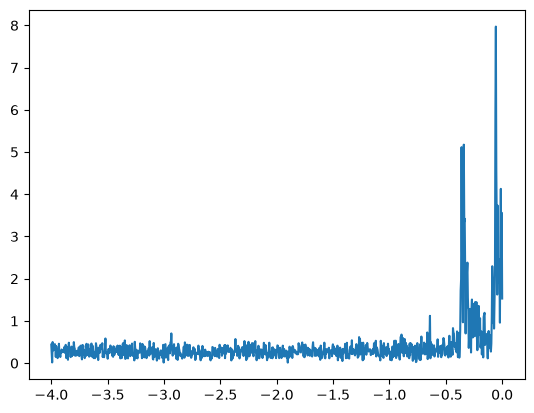

In [48]:
lre = torch.linspace(-4,0,1000)
lrs = 10 ** lre

# learning rate and loss are stored to determine the best

lri = []
lossi = []

for i in range(1000):

    #minibatch construct

    ix = torch.randint(0, X.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[X[ix]] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update

    lr = lrs[i]

    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())


plt.plot(lri,lossi) # using the graph we watn to find ~ the minimum value to determine the lri

In [18]:
for i in range(10000):

    #minibatch construct

    ix = torch.randint(0, X.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[X[ix]] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update

    lr = 0.01 # learning rate decay, in late stages you lower the learning rate as you approach the optimial level
    for p in parameters:
        p.data += -lr * p.grad


In [49]:

emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits,Y)
loss

tensor(1.0189, grad_fn=<NllLossBackward0>)

Overall learning rate is optimized before going through large training sets, after large training sets do learning rate decay as you approach a low loss value

Despite the loss lowering, it could be an issue if it is overfitting (too low of a loss function)

to fix this, split the data set into 3 splits

- training split (~80%), train parameters
- dev/validation split (~10%), train hyperparameters
- test split (~10%), evaluate performance at the end (do it sparingly)

In [50]:
# build dataset

# supports the prediction (3 inputs for the 4th)

block_size = 3 # context length: how many chars do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size # 0 tokens
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context) # stores running context
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

yuheng
... ---> y
..y ---> u
.yu ---> h
yuh ---> e
uhe ---> n
hen ---> g
eng ---> .
diondre
... ---> d
..d ---> i
.di ---> o
dio ---> n
ion ---> d
ond ---> r
ndr ---> e
dre ---> .
xavien
... ---> x
..x ---> a
.xa ---> v
xav ---> i
avi ---> e
vie ---> n
ien ---> .
jori
... ---> j
..j ---> o
.jo ---> r
jor ---> i
ori ---> .
juanluis
... ---> j
..j ---> u
.ju ---> a
jua ---> n
uan ---> l
anl ---> u
nlu ---> i
lui ---> s
uis ---> .


In [51]:
# lets build the dataset

# takes list of words and creates X and Y for training
def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X, Y
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])




torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [22]:
for i in range(10000):

    #minibatch construct

    ix = torch.randint(0, Xtr.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[Xtr[ix]] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update

    lr = 0.01 # learning rate decay, in late stages you lower the learning rate as you approach the optimial level
    for p in parameters:
        p.data += -lr * p.grad

In [52]:
emb = C[Xtr] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ytr)

print(loss.item())

emb = C[Xdev] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ydev)

print(loss.item())

# when the loss of both the testing and the dev network are similar, it is underfitting due to too small of a dataset

14.779922485351562
14.795169830322266


To make another performance improvement, we should increase the number of neurons 

In [53]:
g = torch.Generator().manual_seed(2147863647)
C = torch.randn((27,2),generator=g)
W1 = torch.randn((6,300),generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

In [54]:

lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre
stepi = []
lossi = []

In [55]:

for i in range(30000):

    #minibatch construct


    # if the batch size is too low we would want to increase the 32 value, it can lead to noise
    ix = torch.randint(0, Xtr.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[Xtr[ix]] # (32, 3 ,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update

    lr = 0.1 # learning rate decay, in late stages you lower the learning rate as you approach the optimial level
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.detach())

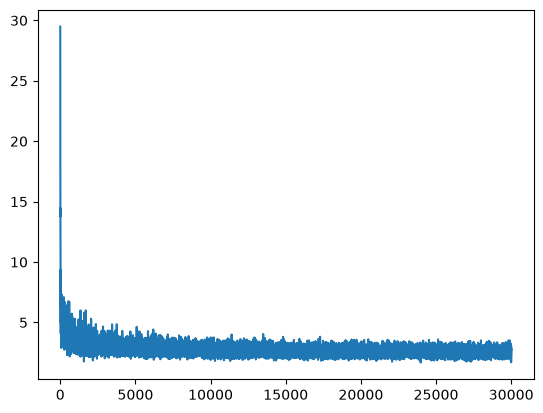

In [56]:
plt.plot(stepi,[loss.item() for loss in lossi])

In [57]:
emb = C[Xtr] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ytr)

print(loss.item())


2.5648274421691895


In [58]:
emb = C[Xdev] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ydev)

print(loss.item())

2.5649542808532715


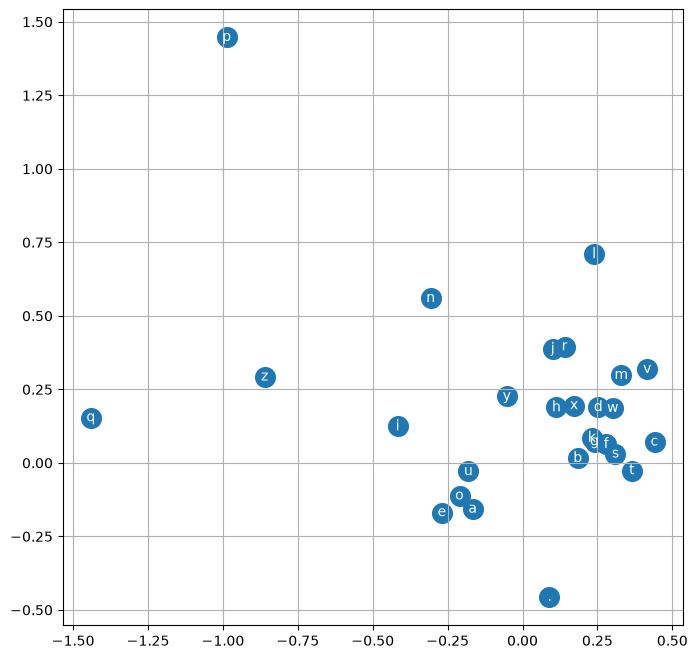

In [59]:
# visualize the characters with embedding coordinates (as there are only 2), (x coords is 0, y coords is 1)

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color="white")
plt.grid('minor')

Stuff to notice about the model

- A, E, I, O, U are clustered together
- Far out points have unique embedding vector (ex q and .)

We see that the loss has not improved drastically despite the increased neural size, this tells us the next place to optimize is our embedding vectors

In [60]:
g = torch.Generator().manual_seed(2147863647)
C = torch.randn((27,10),generator=g)
W1 = torch.randn((30,200),generator=g) # changes to 30 since embedded changed to 10 and we are looking 3 letters ahead
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

In [61]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre
stepi = []
lossi = []

In [74]:

for i in range(1000000):

    #minibatch construct


    # if the batch size is too low we would want to increase the 32 value, it can lead to noise
    ix = torch.randint(0, Xtr.shape[0], (32,)) # rather than sampling all values, chose random and run through loss function

    # forward pass

    emb = C[Xtr[ix]] # (32, 3 ,10)
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (32, 200)
    logits = h @ W2 + b2 # (32, 27)

    loss = F.cross_entropy(logits,Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.detach())

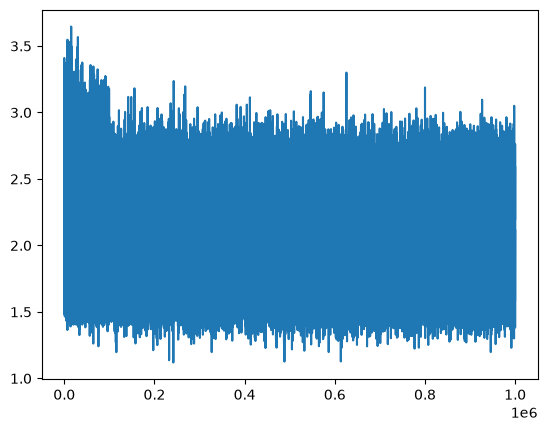

In [75]:
plt.plot(stepi,[loss.item() for loss in lossi])

In [76]:
emb = C[Xtr] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ytr)

print(loss.item())

2.0434489250183105


In [77]:
emb = C[Xdev] # (32, 3 ,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits,Ydev)

print(loss.item())

2.1270394325256348


In [91]:

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

tuberoshelen.
alett.
juece.
metraeylianni.
yavelle.
ram.
dakelco.
laura.
agly.
hain.
day.
jayslinaye.
mayaanv.
mak.
rick.
giffanessia.
lom.
keyannacischyn.
armi.
kaycitahispinn.
